# Crypto Sentiment Screener — Exploratory Data Analysis

Step-by-step walkthrough of the sentiment screener pipeline: generate the headline stream, classify it with the real **FinBERT** model (`ProsusAI/finbert`, via HuggingFace Transformers), then explore the resulting sentiment distribution and its relationship to trading volume.

Every cell below runs for real against the actual model — nothing here is precomputed or pasted in from elsewhere.

## 1. Imports

In [1]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import random

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from sentiment_screener import (
    N_HEADLINES,
    SEED,
    TICKERS,
    classify_sentiment,
    scores_to_row,
    simulate_headlines,
)

pl.Config.set_tbl_rows(10)

polars.config.Config

## 2. Generate the headline stream

`simulate_headlines` produces template-based financial headlines with a **known intended polarity** (positive/negative/neutral) and a simulated trading volume tied to that polarity's intensity. The intended label is never shown to FinBERT — it exists purely so we can check the model's real predictions against it later.

In [2]:
py_rng = random.Random(SEED)
np_rng = np.random.default_rng(SEED)

rows = simulate_headlines(N_HEADLINES, py_rng, np_rng)
headlines_df = pl.DataFrame(rows)

print(f"{headlines_df.height} headlines across {len(TICKERS)} tickers.")
headlines_df.head(10)

240 headlines across 8 tickers.


date,ticker,headline,true_label,volume_usd_millions
date,str,str,str,f64
2024-01-27,"""BTC""","""Analysts maintain hold rating …","""neutral""",3.7453e6
2024-08-20,"""SOL""","""SOL climbs on news of favorabl…","""positive""",8.2702e6
2024-01-26,"""AVAX""","""Analysts maintain hold rating …","""neutral""",2.7227e6
2024-07-28,"""ADA""","""ADA rallies after major exchan…","""positive""",4.4419e6
2024-08-08,"""ADA""","""ADA trades sideways ahead of u…","""neutral""",4.8250e6
2024-08-16,"""MATIC""","""Network outage sparks MATIC se…","""negative""",8.7337e6
2024-09-08,"""SOL""","""SOL plunges 16% after exchange…","""negative""",1.0852e7
2024-05-15,"""SOL""","""SOL slides after downgrade fro…","""negative""",8.9866e6
2024-08-22,"""ETH""","""Regulators announce crackdown …","""negative""",1.1595e7


## 3. Classify sentiment with FinBERT

This loads the real, pretrained `ProsusAI/finbert` model from the HuggingFace Hub (cached locally after the first download) and runs it over every headline, batched.

In [3]:
headlines = headlines_df["headline"].to_list()
raw_results = classify_sentiment(headlines)

predicted_labels, sentiment_scores = [], []
for result in raw_results:
    predicted_label, sentiment_score, _ = scores_to_row(result)
    predicted_labels.append(predicted_label)
    sentiment_scores.append(sentiment_score)

df = headlines_df.with_columns(
    [
        pl.Series("predicted_label", predicted_labels),
        pl.Series("sentiment_score", sentiment_scores),
    ]
)
df.head(10)

date,ticker,headline,true_label,volume_usd_millions,predicted_label,sentiment_score
date,str,str,str,f64,str,f64
2024-01-27,"""BTC""","""Analysts maintain hold rating …","""neutral""",3.7453e6,"""negative""",-0.676946
2024-08-20,"""SOL""","""SOL climbs on news of favorabl…","""positive""",8.2702e6,"""positive""",0.702754
2024-01-26,"""AVAX""","""Analysts maintain hold rating …","""neutral""",2.7227e6,"""negative""",-0.7742
2024-07-28,"""ADA""","""ADA rallies after major exchan…","""positive""",4.4419e6,"""neutral""",-0.094632
2024-08-08,"""ADA""","""ADA trades sideways ahead of u…","""neutral""",4.8250e6,"""negative""",-0.492731
2024-08-16,"""MATIC""","""Network outage sparks MATIC se…","""negative""",8.7337e6,"""negative""",-0.953561
2024-09-08,"""SOL""","""SOL plunges 16% after exchange…","""negative""",1.0852e7,"""negative""",-0.825061
2024-05-15,"""SOL""","""SOL slides after downgrade fro…","""negative""",8.9866e6,"""negative""",-0.68579
2024-08-22,"""ETH""","""Regulators announce crackdown …","""negative""",1.1595e7,"""negative""",-0.920918


## 4. How does FinBERT's label distribution look?

In [4]:
df.group_by("predicted_label").agg(pl.len().alias("n_headlines")).sort("predicted_label")

predicted_label,n_headlines
str,u32
"""negative""",109
"""neutral""",39
"""positive""",92


## 5. Sentiment score histogram

`sentiment_score = P(positive) - P(negative)`, so it ranges from -1 (fully negative) to +1 (fully positive), with 0 meaning either a neutral call or positive/negative probabilities cancelling out.

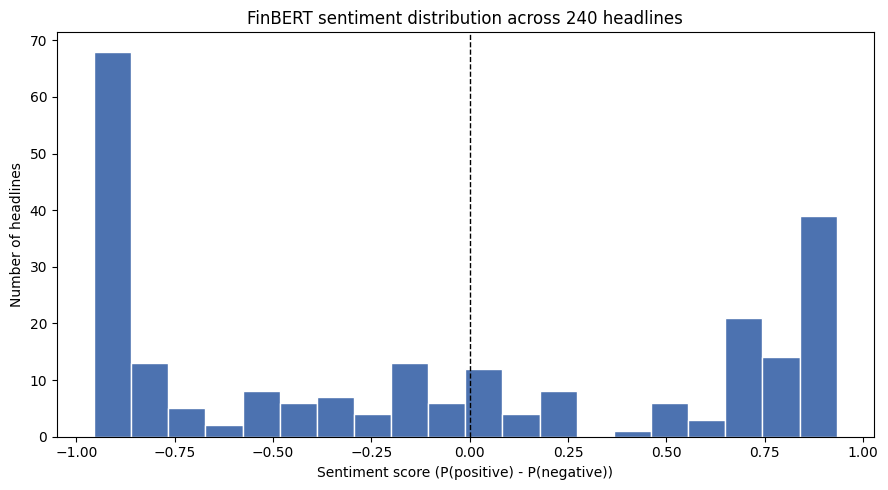

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["sentiment_score"].to_numpy(), bins=20, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Sentiment score (P(positive) - P(negative))")
ax.set_ylabel("Number of headlines")
ax.set_title(f"FinBERT sentiment distribution across {df.height} headlines")
fig.tight_layout()
plt.show()

The distribution is bimodal and skewed toward strong conviction at both ends rather than clustering near zero — FinBERT rarely lands near a neutral 0.0 score, even for headlines written to be neutral (see the class-recall breakdown in the README's §6.1).

## 6. Sentiment vs. volume, per ticker

Grouped bar chart: average sentiment score and average simulated trading volume, per crypto ticker — the core screener output. A ticker with a strongly polarized average sentiment *and* high volume is the one a screener should surface first.

In [6]:
by_ticker = (
    df.group_by("ticker")
    .agg(
        [
            pl.col("sentiment_score").mean().alias("avg_sentiment"),
            pl.col("volume_usd_millions").mean().alias("avg_volume"),
            pl.len().alias("n_headlines"),
        ]
    )
    .sort("ticker")
)
by_ticker

ticker,avg_sentiment,avg_volume,n_headlines
str,f64,f64,u32
"""ADA""",-0.068127,6.5736e6,30
"""AVAX""",0.019249,6.8075e6,31
"""BTC""",-0.036137,7.6838e6,24
"""DOT""",0.004744,6.5935e6,30
"""ETH""",-0.24042,6.6846e6,24
"""MATIC""",-0.254004,6.8670e6,35
"""SOL""",-0.156644,7.0261e6,31
"""XRP""",-0.027431,7.7933e6,35


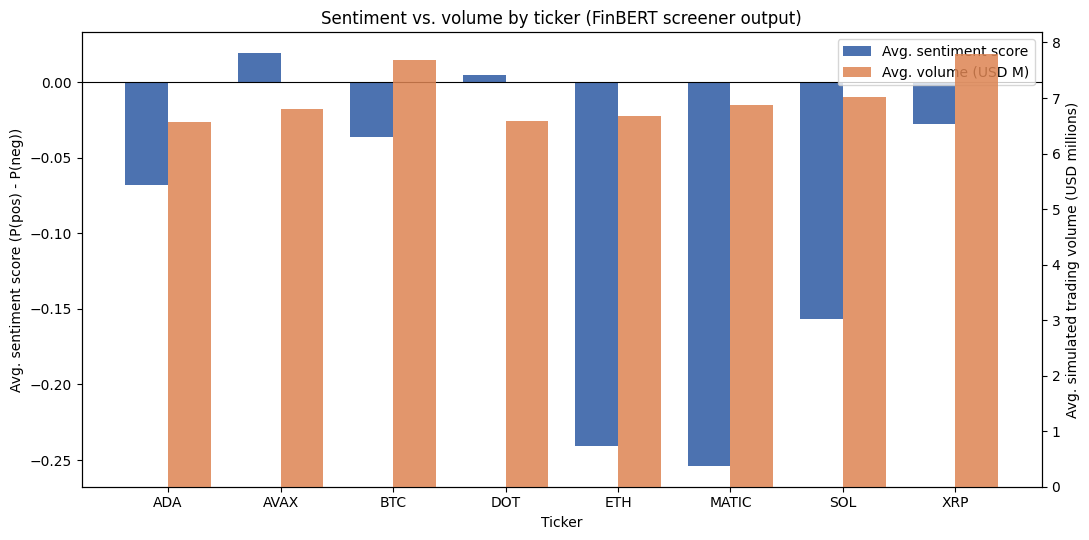

In [7]:
tickers = by_ticker["ticker"].to_list()
avg_sentiment = by_ticker["avg_sentiment"].to_numpy()
avg_volume_millions = by_ticker["avg_volume"].to_numpy() / 1e6

x = np.arange(len(tickers))
width = 0.38

fig, ax1 = plt.subplots(figsize=(11, 5.5))
bars_sentiment = ax1.bar(
    x - width / 2, avg_sentiment, width, color="#4C72B0", label="Avg. sentiment score"
)
ax1.set_ylabel("Avg. sentiment score (P(pos) - P(neg))")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(tickers)
ax1.set_xlabel("Ticker")

ax2 = ax1.twinx()
bars_volume = ax2.bar(
    x + width / 2, avg_volume_millions, width, color="#DD8452", alpha=0.85, label="Avg. volume (USD M)"
)
ax2.set_ylabel("Avg. simulated trading volume (USD millions)")

lines = [bars_sentiment, bars_volume]
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
ax1.set_title("Sentiment vs. volume by ticker (FinBERT screener output)")
fig.tight_layout()
plt.show()

## 7. Most polarizing headlines

The 5 headlines FinBERT scored most negatively and most positively — a quick sanity check that the extreme scores correspond to headlines a human would actually read as extreme.

In [8]:
print("Most negative:")
display(df.sort("sentiment_score").head(5).select(["ticker", "headline", "sentiment_score"]))

print("\nMost positive:")
display(df.sort("sentiment_score", descending=True).head(5).select(["ticker", "headline", "sentiment_score"]))

Most negative:


ticker,headline,sentiment_score
str,str,f64
"""ADA""","""ADA falls to multi-month low a…",-0.955413
"""MATIC""","""Liquidity concerns weigh on MA…",-0.955014
"""MATIC""","""Liquidity concerns weigh on MA…",-0.955014
"""XRP""","""Network outage sparks XRP sell…",-0.954203
"""XRP""","""XRP falls to multi-month low a…",-0.954099



Most positive:


ticker,headline,sentiment_score
str,str,f64
"""XRP""","""XRP surges 21% as institutiona…",0.932845
"""XRP""","""XRP surges 21% as institutiona…",0.932845
"""BTC""","""BTC surges 10% as institutiona…",0.932688
"""XRP""","""XRP surges 7% as institutional…",0.932509
"""ADA""","""ADA surges 15% as institutiona…",0.932345


## 8. Takeaways

- The sentiment histogram (§5) is bimodal, not centered on zero — FinBERT commits to a polarized read far more often than it lands near neutral.
- The sentiment-vs-volume bar chart (§6) is the screener's actual deliverable: it turns unstructured headline text into a per-asset, rankable table that a desk could sort by conviction or by volume.
- The most-polarizing headlines (§7) read as genuinely extreme to a human, which is a reasonable qualitative check that the model's confidence is tracking real textual signal, not noise.
- See `README.md` §6.1 for the quantified accuracy/confusion-matrix check against each headline's intended polarity, run from `sentiment_screener.py` directly.